In [1]:
import sys
MODULEPATH="../../"
sys.path.append(MODULEPATH)
sys.path.append('../')
from connectivity.plot_results import plot_results_with_paths, plot_saddle_tree_with_function, plot_full_connectivity_tree_style

from critical_points.jax_critical_point_finder import jax_find_critical_points, save_critical_points_to_csv
from test_schwefel.schwefel_function_jax import Schwefel2D, schwefel_loss 

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
model_builder = lambda p: Schwefel2D(*p)

In [3]:
# Set parameters
BOUNDS = {'x1': (0.0, 1.0), 'x2': (0.0, 1.0)}
DIM = 2
ATTEMPTS = 64
MIN_DISTANCE = 0.01


In [4]:
try:
    resume_df = pd.read_csv("critical_points_schwefel_jax.csv", index_col=0)
    display(resume_df)
except FileNotFoundError:
    resume_df = None


In [5]:
# Run search
minima, maxima, saddles = jax_find_critical_points(
    model_builder=model_builder,
    loss_func=schwefel_loss,
    input = [],             # placeholder model input for compatibility (Schwefel model has no model input)
    minima_only=False,
    bounds=BOUNDS,
    dimension=DIM,
    num_attempts=ATTEMPTS,
    min_distance=MIN_DISTANCE,
    lr=5e-2,
    max_iter=5_000,
    resume_df=resume_df,  
    seed=1101
)



__________________________________________________________________________________________
Attempt 1/64:
Starting point: [0.36986873 0.86725748]
Learning rate: 0.05
Converged after 243 iterations.
Arrival point: [0.34180955 0.82437514]
check grad: [5.20709972e-06 7.81709039e-06]
Converged to critical point with ||grad||=9.39e-06 < 1e-05
New critical point found at [0.34180955 0.82437514] with value 0.217140
Type: minimum

__________________________________________________________________________________________
Attempt 2/64:
Starting point: [0.94715009 0.30818178]
Learning rate: 0.05
Converged after 256 iterations.
Arrival point: [0.82437516 0.34180939]
check grad: [ 8.66194268e-06 -3.03652079e-06]
Converged to critical point with ||grad||=9.18e-06 < 1e-05
New critical point found at [0.82437516 0.34180939] with value 0.217140
Type: minimum

__________________________________________________________________________________________
Attempt 3/64:
Starting point: [0.51134947 0.74875455]


In [6]:
# Save to CSV
results_df = save_critical_points_to_csv(minima, maxima, saddles, dimension=DIM, filename="critical_points_schwefel_jax.csv")

results_df = pd.concat((resume_df,results_df), ignore_index=True)

display(results_df)

Saved critical_points_schwefel_jax.csv


,x1,x2,f_value,type,index
0,0.341810,0.824375,2.171397e-01,minimum,0
1,0.824375,0.341809,2.171397e-01,minimum,0
2,0.824375,0.824375,2.545597e-08,minimum,0
3,0.034551,0.341810,5.724876e-01,minimum,0
4,0.341809,0.034551,5.724876e-01,minimum,0
5,0.824375,0.034551,3.553479e-01,minimum,0
6,0.034551,0.824375,3.553479e-01,minimum,0
7,0.034551,0.034551,7.106958e-01,minimum,0
8,0.341809,0.341809,4.342794e-01,minimum,0
9,0.166288,0.166288,1.083718e+00,maximum,2


/tmp/ipykernel_2373087/169460614.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()


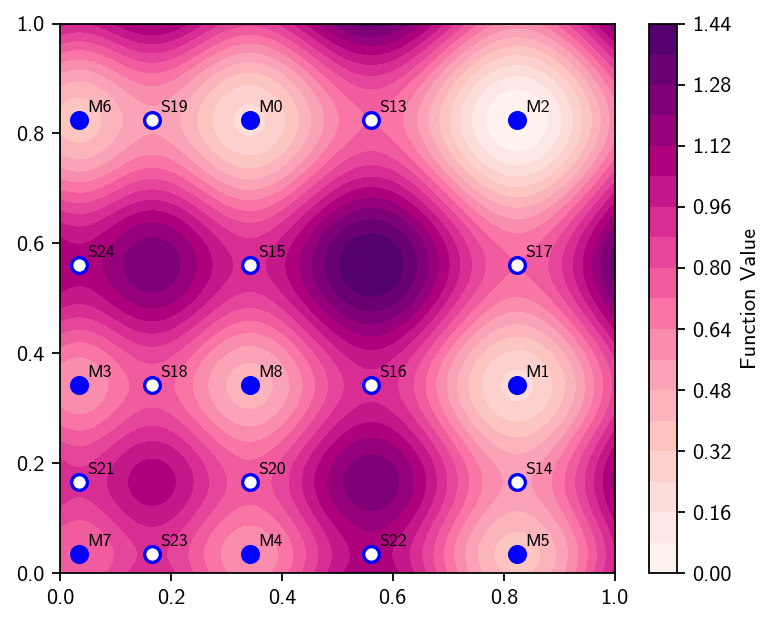

In [7]:
from schwefel_function_jax import _schwefel
schwefel2D_numpy = _schwefel

fig2 = plt.figure(figsize=(5,4), dpi=160)
fig2 = plot_results_with_paths(func=schwefel2D_numpy,  
                                critical_points_df=results_df,
                                connectivity_df=None, 
                                bounds=(0, 1),
                                res=200,
                                fig=fig2
)
plt.xlim(*BOUNDS['x1'])
plt.ylim(*BOUNDS['x2'])
fig2.show()
# fig2.savefig("plots/landscape_paths.png")  # Optional